# F1 Historical Weather Fetcher

Fetches historical weather for every race in `event_location_data.csv` using the **Open-Meteo Archive API** (free, no key required).  

This notebook collects a **5-hour window** around each race start
(−2 h to +2 h, inclusive), enabling analysis that a single-timestamp snapshot misses:

| Problem with single timestamp | Fix in this notebook |
|---|---|
| Track wet from earlier rain, reads dry at start | Pre-race precipitation sum (−2 h to 0) |
| Rain starts mid-race, reads dry at start | Post-race precipitation sum (0 to +2 h) |
| Condition worsened / improved through race | Weather trend slope (linear fit over window) |
| Transient shower vs sustained rain | Max hourly intensity vs. total accumulation |
| Single bad hour inflates "wet race" count | Require ≥ 2 wet hours in window |

## Data-science angles included
- Weather volatility score: std-dev of precipitation and temperature over the window; high volatility = unpredictable race
- Condition transition detection: did the race go wet→dry or dry→wet during the window?
- Thermal swing: max minus min temperature across the window (affects tyre degradation)
- Season calendar heatmap: precipitation and temperature across rounds × years


In [1]:
%pip install -q requests pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import json
import hashlib
from pathlib import Path
from datetime import datetime, timezone, timedelta

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
print("Libraries loaded.")

Libraries loaded.


## Load event data

In [3]:
events = pd.read_csv("../data/event_location_data.csv", parse_dates=["StartTime"])
events["StartTime"] = pd.to_datetime(events["StartTime"], utc=True)

print(f"Events loaded: {len(events)}  |  Years: {events['Year'].min()}–{events['Year'].max()}")
events.head()

Events loaded: 173  |  Years: 2018–2025


,EventName,Country,Location,StartTime,Year,lon,lat
0,Australian Grand Prix,Australia,Melbourne,2018-03-25 05:10:00+00:00,2018,144.97,-37.85
1,Bahrain Grand Prix,Bahrain,Sakhir,2018-04-08 15:10:00+00:00,2018,50.51,26.03
2,Chinese Grand Prix,China,Shanghai,2018-04-15 06:10:00+00:00,2018,121.22,31.34
3,Azerbaijan Grand Prix,Azerbaijan,Baku,2018-04-29 12:10:00+00:00,2018,49.84,40.37
4,Spanish Grand Prix,Spain,Barcelona,2018-05-13 13:10:00+00:00,2018,2.26,41.57


## Configuration

In [4]:
# Hours relative to race start to include in the window.
# −2 = 2 hours before start, +2 = 2 hours after start.
WINDOW_HOURS = list(range(-2, 3))   # [-2, -1, 0, 1, 2]

HOURLY_VARS = [
    "temperature_2m",
    "apparent_temperature",
    "relative_humidity_2m",
    "dew_point_2m",
    "precipitation",
    "rain",
    "showers",
    "snowfall",
    "weather_code",
    "cloud_cover",
    "surface_pressure",
    "wind_speed_10m",
    "wind_gusts_10m",
    "wind_direction_10m",
]

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"
output_path = "../data/f1_race_weather_data.csv"

# WMO weather code descriptions (https://open-meteo.com/en/docs#weather_variable_documentation)
WMO_DESCRIPTIONS = {
    0: "Clear sky", 1: "Mainly clear", 2: "Partly cloudy", 3: "Overcast",
    45: "Fog", 48: "Depositing rime fog",
    51: "Light drizzle", 53: "Moderate drizzle", 55: "Dense drizzle",
    61: "Slight rain", 63: "Moderate rain", 65: "Heavy rain",
    71: "Slight snow", 73: "Moderate snow", 75: "Heavy snow",
    77: "Snow grains",
    80: "Slight showers", 81: "Moderate showers", 82: "Violent showers",
    85: "Slight snow showers", 86: "Heavy snow showers",
    95: "Thunderstorm", 96: "Thunderstorm w/ slight hail", 99: "Thunderstorm w/ heavy hail",
}

# WMO codes that indicate precipitation is occurring
WET_CODES = {51, 53, 55, 61, 63, 65, 71, 73, 75, 77, 80, 81, 82, 85, 86, 95, 96, 99}

print(f"Window: {WINDOW_HOURS[0]}h to +{WINDOW_HOURS[-1]}h ({len(WINDOW_HOURS)} hours)")
print(f"Variables per hour: {len(HOURLY_VARS)}")

Window: -2h to +2h (5 hours)
Variables per hour: 14


## Fetch helpers

In [5]:
def fetch_hourly_day(lat: float, lon: float, date: str, retries: int = 3) -> dict | None:
    params = {
        "latitude": round(lat, 4),
        "longitude": round(lon, 4),
        "start_date": date,
        "end_date": date,
        "hourly": ",".join(HOURLY_VARS),
        "timezone": "UTC",
    }

    for attempt in range(retries):
        try:
            resp = requests.get(ARCHIVE_URL, params=params, timeout=20)
            if resp.status_code == 200:
                data = resp.json()
                return data
            elif resp.status_code == 429:
                time.sleep(2 ** attempt)
            else:
                print(f"  HTTP {resp.status_code} for {lat},{lon} {date}: {resp.text[:120]}")
                return None
        except requests.RequestException as exc:
            print(f"  Request error attempt {attempt+1}: {exc}")
            time.sleep(1)
    return None


def extract_hour_slice(payload: dict, target_hour: int) -> dict:
    hourly = payload.get("hourly", {})
    times = hourly.get("time", [])
    idx = next(
        (i for i, t in enumerate(times) if int(t.split("T")[1].split(":")[0]) == target_hour),
        None,
    )
    if idx is None:
        return {}
    return {var: hourly[var][idx] for var in HOURLY_VARS if var in hourly}


print("Fetch helpers defined.")

Fetch helpers defined.


## Fetch multi-hour window for all races

Each race collects 5 hourly slices (−2 h → +2 h).  
When the window crosses midnight UTC, two calendar-day requests are needed — both cached independently.

In [6]:
records = []   # one row per race

if not Path(output_path).is_file():
    skipped = []
    for _, row in events.iterrows():
        start_utc: pd.Timestamp = row["StartTime"]
    
        # Gather hourly slices across the window
        window_slices = {}   # offset_h -> {var: value}
        day_cache: dict[str, dict | None] = {}   # avoids double-fetch
    
        for offset_h in WINDOW_HOURS:
            target_ts = start_utc + pd.Timedelta(hours=offset_h)
            date_str = target_ts.strftime("%Y-%m-%d")
            target_hour = target_ts.hour
    
            if date_str not in day_cache:
                payload = fetch_hourly_day(row["lat"], row["lon"], date_str)
                day_cache[date_str] = payload
                # Polite delay
                if payload is not None:
                    time.sleep(0.25)
            else:
                payload = day_cache[date_str]
    
            if payload:
                window_slices[offset_h] = extract_hour_slice(payload, target_hour)
    
        if not window_slices:
            skipped.append(row["EventName"])
            continue
    
        # Flatten into per race record
        rec = {
            "EventName": row["EventName"],
            "Country":   row["Country"],
            "Location":  row["Location"],
            "Year":      row["Year"],
            "StartTime": start_utc,
            "lat":       row["lat"],
            "lon":       row["lon"],
        }
    
        # Store each hour's raw values with suffixed column names
        for h, slc in window_slices.items():
            suffix = f"_h{h:+d}".replace("+", "p").replace("-", "m")
            for var, val in slc.items():
                rec[f"{var}{suffix}"] = val
    
        records.append(rec)
    
    print(f"Fetched : {len(records)} events")
    if skipped:
        print(f"Skipped : {len(skipped)} — {skipped}")

## Build raw DataFrame and derive window-level features

In [7]:
if Path(output_path).is_file():
    raw = pd.read_csv(output_path)
else:
    raw = pd.DataFrame(records)

    # Collects one variable across the window. Returns a sub-DataFrame with one column per window hour for `var`.
    def window_series(df: pd.DataFrame, var: str) -> pd.DataFrame:
        cols = {}
        for h in WINDOW_HOURS:
            suffix = f"_{var}_h{h:+d}".replace("+", "p").replace("-", "m")
            col = f"{var}_h{h:+d}".replace("+", "p").replace("-", "m")
            if col in df.columns:
                cols[h] = df[col]
        return pd.DataFrame(cols)
    
    
    # Precipitation window series
    precip_w = window_series(raw, "precipitation")
    
    raw["precip_pre2h"]   = precip_w[[-2, -1]].sum(axis=1, min_count=1)   # rain in 2 h before start
    raw["precip_at_start"] = precip_w[[0]].sum(axis=1, min_count=1)        # original single-hour metric
    raw["precip_post2h"]  = precip_w[[1, 2]].sum(axis=1, min_count=1)     # rain in 2 h after start
    raw["precip_total"]   = precip_w.sum(axis=1, min_count=1)             # full 5-hour accumulation
    raw["precip_max_hr"]  = precip_w.max(axis=1)                          # worst single hour
    
    # Wet-race classification
    # Any precipitation at start hour
    raw["is_wet_start"]   = raw["precip_at_start"] > 0.1
    
    # Track was wet before the race (residual water on track)
    raw["track_wet_pre"]  = raw["precip_pre2h"] > 0.2
    
    # Rain developed during the race window
    raw["rain_during"]    = raw["precip_post2h"] > 0.2
    
    # Broad "affected by rain" flag (any of the above)
    raw["is_wet_broad"]   = raw["is_wet_start"] | raw["track_wet_pre"] | raw["rain_during"]
    
    # Sustained wet (≥2 h with precipitation in window, using wet WMO codes)
    wmo_w = window_series(raw, "weather_code")
    raw["wet_hours_count"] = wmo_w.apply(lambda row: sum(v in WET_CODES for v in row.dropna()), axis=1)
    raw["is_wet_sustained"] = raw["wet_hours_count"] >= 2
    
    # Condition transitions
    pre_wet  = precip_w[[-2, -1]].max(axis=1) > 0.1
    post_wet = precip_w[[1, 2]].max(axis=1) > 0.1
    start_wet = precip_w[[0]].max(axis=1) > 0.1
    
    raw["transition_dry_to_wet"] = (~pre_wet) & (post_wet | start_wet)   # started dry, went wet
    raw["transition_wet_to_dry"] = (pre_wet)  & (~post_wet & ~start_wet) # started wet, dried out
    
    # Temperature window features
    temp_w = window_series(raw, "temperature_2m")
    raw["temp_at_start"]  = temp_w[[0]].squeeze()
    raw["temp_swing"]     = temp_w.max(axis=1) - temp_w.min(axis=1)    # thermal range across window
    raw["temp_trend"]     = temp_w.apply(                               # +ve = warming, -ve = cooling
        lambda row: np.polyfit(range(len(row.dropna())), row.dropna(), 1)[0]
        if len(row.dropna()) >= 2 else np.nan,
        axis=1,
    )
    
    # Dew-point margin trajectory
    # Small or shrinking margin → condensation / slippery track risk
    dp_w   = window_series(raw, "dew_point_2m")
    margin_w = temp_w.values - dp_w.values   # shape (n_races, n_hours); positive = dry air
    raw["dewpoint_margin_start"] = margin_w[:, WINDOW_HOURS.index(0)]
    raw["dewpoint_margin_min"]   = np.nanmin(margin_w, axis=1)          # worst moment
    raw["dewpoint_margin_trend"] = np.array([
        np.polyfit(range(len(row := margin_w[i][~np.isnan(margin_w[i])])), row, 1)[0]
        if (~np.isnan(margin_w[i])).sum() >= 2 else np.nan
        for i in range(len(margin_w))
    ])  # -ve trend = converging toward condensation during race
    
    # Wind volatility
    gust_w = window_series(raw, "wind_gusts_10m")
    wspd_w = window_series(raw, "wind_speed_10m")
    raw["wind_gust_max"]   = gust_w.max(axis=1)
    raw["wind_gust_spike"] = gust_w.max(axis=1) - wspd_w.mean(axis=1)   # sudden gust above mean speed
    
    # Overall weather volatility score (normalized)
    # High score = conditions changed a lot during the window
    raw["volatility_precip"] = precip_w.std(axis=1)
    raw["volatility_temp"]   = temp_w.std(axis=1)
    raw["volatility_score"]  = (
        raw["volatility_precip"].fillna(0) * 5   # weight rain variability more heavily
        + raw["volatility_temp"].fillna(0)
    )
    
    # WMO label at race start
    start_code_col = "weather_code_h+0".replace("+", "p")
    if start_code_col in raw.columns:
        raw["condition_start"] = raw[start_code_col].map(WMO_DESCRIPTIONS).fillna("Unknown")
    
    print(f"DataFrame shape: {raw.shape}")
    print("\nWet-flag summary:")
    for col in ["is_wet_start", "track_wet_pre", "rain_during", "is_wet_broad", "is_wet_sustained"]:
        n = raw[col].sum()
        print(f"  {col:<22}: {n:3d} / {len(raw)}  ({n/len(raw)*100:.1f}%)")

## Save extended dataset to CSV if not in file yet

In [8]:
if not Path(output_path).is_file():
    raw.to_csv(output_path, index=False)
    print(f"Saved into {output_path}  ({len(raw)} rows × {len(raw.columns)} columns)")

# Compact summary table
summary_cols = [
    "Year", "EventName", "Location",
    "precip_pre2h", "precip_at_start", "precip_post2h", "precip_total",
    "is_wet_start", "track_wet_pre", "rain_during", "is_wet_broad", "is_wet_sustained",
    "transition_dry_to_wet", "transition_wet_to_dry",
    "temp_at_start", "temp_swing", "temp_trend",
    "dewpoint_margin_start", "dewpoint_margin_min",
    "wind_gust_max", "wind_gust_spike",
    "volatility_score", "wet_hours_count",
]
summary_cols = [c for c in summary_cols if c in raw.columns]
raw[summary_cols].head(10)

,Year,EventName,Location,precip_pre2h,precip_at_start,precip_post2h,precip_total,is_wet_start,track_wet_pre,rain_during,is_wet_broad,is_wet_sustained,transition_dry_to_wet,transition_wet_to_dry,temp_at_start,temp_swing,temp_trend,dewpoint_margin_start,dewpoint_margin_min,wind_gust_max,wind_gust_spike,volatility_score,wet_hours_count
0,2018,Australian Grand Prix,Melbourne,0.00,0.00,0.00,0.00,False,False,False,False,False,False,False,23.40,1.90,0.11,16.40,11.20,54.40,27.32,0.83,0
1,2018,Bahrain Grand Prix,Sakhir,0.00,0.00,0.00,0.00,False,False,False,False,False,False,False,27.40,4.20,-1.08,13.70,8.90,33.50,18.12,1.72,0
2,2018,Chinese Grand Prix,Shanghai,0.00,0.00,0.00,0.00,False,False,False,False,False,False,False,18.30,0.40,-0.02,16.80,16.50,34.20,20.20,0.16,0
3,2018,Azerbaijan Grand Prix,Baku,0.00,0.00,0.00,0.00,False,False,False,False,False,False,False,15.60,3.00,-0.73,8.20,6.70,74.20,33.50,1.16,0
4,2018,Spanish Grand Prix,Barcelona,0.10,2.60,1.40,4.10,True,False,True,True,True,True,False,14.90,1.10,-0.14,7.10,7.10,40.30,26.58,5.80,4
5,2018,Monaco Grand Prix,Monaco,0.00,0.30,0.10,0.40,True,False,False,True,True,True,False,25.40,2.70,-0.58,5.70,5.70,58.30,43.60,1.75,2
6,2018,Canadian Grand Prix,Montréal,0.00,0.00,0.00,0.00,False,False,False,False,False,False,False,19.00,1.80,0.47,14.80,14.30,24.50,19.36,0.76,0
7,2018,French Grand Prix,Le Castellet,0.00,0.00,0.00,0.00,False,False,False,False,False,False,False,22.10,1.50,-0.39,9.70,9.70,33.50,27.64,0.71,0
8,2018,Austrian Grand Prix,Spielberg,0.00,0.00,0.00,0.00,False,False,False,False,False,False,False,18.40,1.90,0.37,7.80,7.00,35.60,27.92,0.76,0
9,2018,British Grand Prix,Silverstone,0.00,0.00,0.00,0.00,False,False,False,False,False,False,False,27.40,3.30,0.85,15.30,13.20,31.00,17.80,1.35,0


## Summary statistics

In [9]:
stat_cols = [
    "precip_pre2h", "precip_at_start", "precip_post2h", "precip_total", "precip_max_hr",
    "temp_at_start", "temp_swing", "temp_trend",
    "dewpoint_margin_start", "dewpoint_margin_min", "dewpoint_margin_trend",
    "wind_gust_max", "wind_gust_spike",
    "volatility_score", "wet_hours_count",
]
stat_cols = [c for c in stat_cols if c in raw.columns]
raw[stat_cols].describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
precip_pre2h,173.00,0.25,0.94,0.00,0.00,0.00,0.10,6.80
precip_at_start,173.00,0.13,0.40,0.00,0.00,0.00,0.00,2.60
precip_post2h,173.00,0.16,0.62,0.00,0.00,0.00,0.00,4.60
precip_total,173.00,0.55,1.51,0.00,0.00,0.00,0.40,11.20
precip_max_hr,173.00,0.32,0.93,0.00,0.00,0.00,0.20,6.60
temp_at_start,173.00,22.92,4.93,8.50,19.40,22.90,26.80,34.70
temp_swing,173.00,2.23,1.30,0.30,1.30,2.00,2.80,7.70
temp_trend,173.00,-0.16,0.57,-2.08,-0.51,-0.13,0.22,1.29
dewpoint_margin_start,173.00,10.01,5.40,1.00,6.00,9.00,13.10,30.90
dewpoint_margin_min,173.00,8.00,4.53,0.80,4.70,7.30,10.10,23.30


## Visualisations

### Wet-flag comparison: single-hour vs. extended window

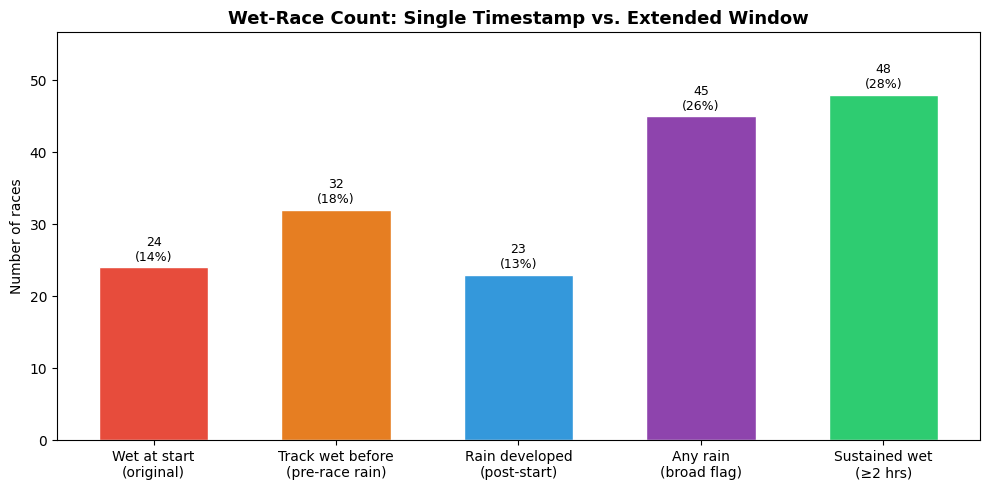

In [10]:
flag_labels = {
    "is_wet_start":     "Wet at start\n(original)",
    "track_wet_pre":    "Track wet before\n(pre-race rain)",
    "rain_during":      "Rain developed\n(post-start)",
    "is_wet_broad":     "Any rain\n(broad flag)",
    "is_wet_sustained": "Sustained wet\n(≥2 hrs)",
}
flag_counts = {lbl: raw[col].sum() for col, lbl in flag_labels.items()}

fig, ax = plt.subplots(figsize=(10, 5))
red = "#e74c3c"
orange = "#e67e22"
blue = "#3498db"
purple = "#8e44ad"
green = "#2ecc71"
yellow = "#f1c40f"

colors = [red, orange, blue, purple, green]
bars = ax.bar(flag_counts.keys(), flag_counts.values(), color=colors, edgecolor="white", width=0.6)

for bar, (lbl, n) in zip(bars, flag_counts.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{n}\n({n/len(raw)*100:.0f}%)", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Number of races")
ax.set_title("Wet-Race Count: Single Timestamp vs. Extended Window", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(flag_counts.values()) * 1.18)
plt.tight_layout()
# plt.savefig("wet_flag_comparison.png", dpi=150)
plt.show()

### Precipitation timeline: pre-race, start, post-race

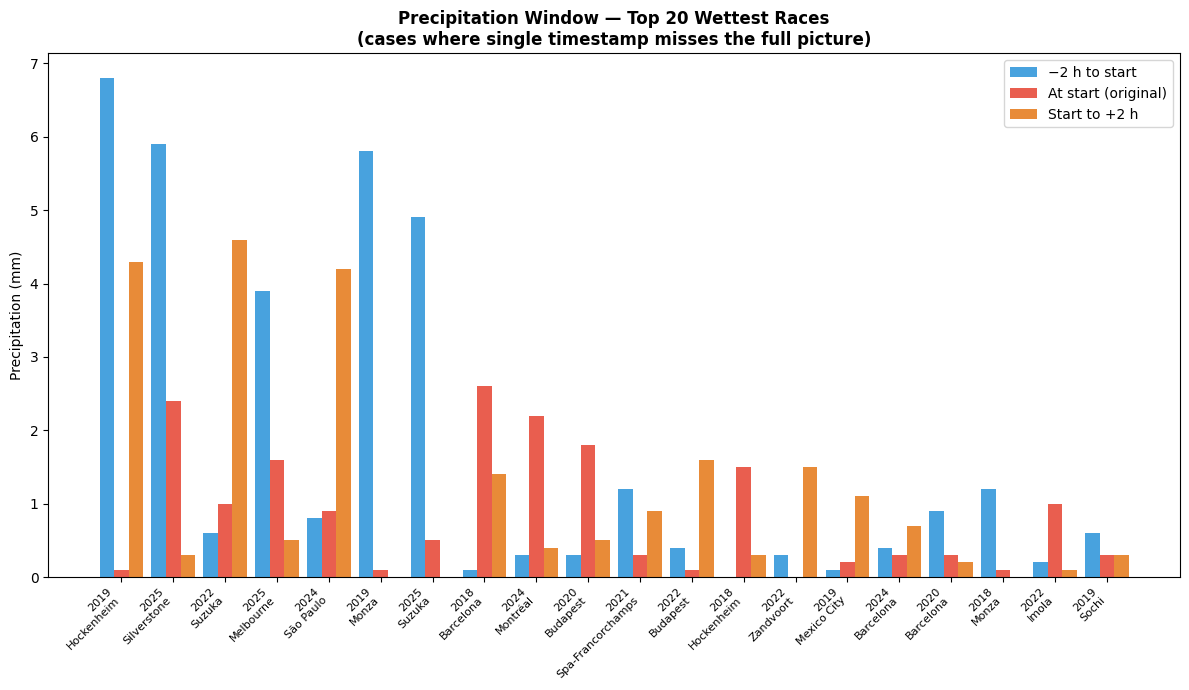

In [11]:
# Select races that had any notable precipitation anywhere in the window
top_number_of_races = 20
notable = raw[raw["precip_total"] > 0.5].copy().sort_values("precip_total", ascending=False).head(top_number_of_races)

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(notable))
width = 0.28

ax.bar(x - width, notable["precip_pre2h"],  width, label="−2 h to start", color=blue, alpha=0.9)
ax.bar(x,          notable["precip_at_start"], width, label="At start (original)", color=red, alpha=0.9)
ax.bar(x + width, notable["precip_post2h"], width, label="Start to +2 h", color=orange, alpha=0.9)

labels = [f"{r['Year']}\n{r['Location']}" for _, r in notable.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Precipitation (mm)")
ax.set_title(f"Precipitation Window — Top {top_number_of_races} Wettest Races\n(cases where single timestamp misses the full picture)",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
# plt.savefig("precip_window_timeline.png", dpi=150)
plt.show()

### Condition transition matrix

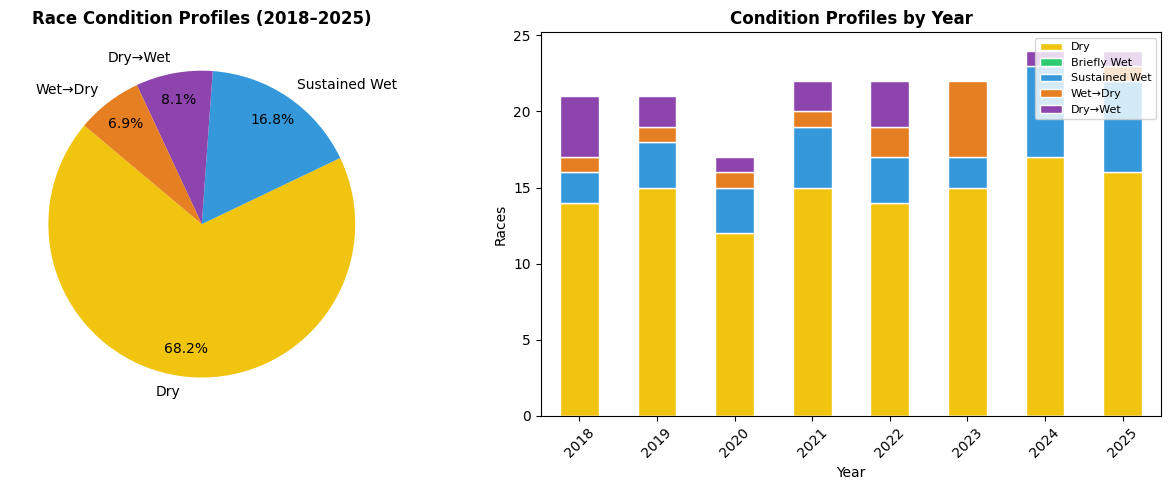

Condition profile counts:
race_condition_profile
Dry              118
Sustained Wet     29
Dry→Wet           14
Wet→Dry           12


In [18]:
# Categorise each race into 4 condition profiles
def classify_condition(row):
    if row["transition_dry_to_wet"]:
        return "Dry→Wet"
    if row["transition_wet_to_dry"]:
        return "Wet→Dry"
    if row["is_wet_sustained"]:
        return "Sustained Wet"
    if row["is_wet_start"] or row["track_wet_pre"]:
        return "Briefly Wet"
    return "Dry"

raw["race_condition_profile"] = raw.apply(classify_condition, axis=1)

profile_counts = raw["race_condition_profile"].value_counts()
profile_colors = {
    "Dry": yellow,
    "Briefly Wet": green,
    "Sustained Wet": blue,
    "Wet→Dry": orange,
    "Dry→Wet": purple,
}
colors_pie = [profile_colors.get(p, red) for p in profile_counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
ax1.pie(profile_counts, labels=profile_counts.index, autopct="%1.1f%%",
        colors=colors_pie, startangle=140, pctdistance=0.82)
ax1.set_title("Race Condition Profiles (2018–2025)", fontsize=12, fontweight="bold")

# Year breakdown
profile_year = raw.groupby(["Year", "race_condition_profile"]).size().unstack(fill_value=0)
profile_year = profile_year.reindex(columns=list(profile_colors.keys()), fill_value=0)
profile_year.plot(kind="bar", ax=ax2, color=[profile_colors[c] for c in profile_year.columns],
                  edgecolor="white", stacked=True)
ax2.set_title("Condition Profiles by Year", fontsize=12, fontweight="bold")
ax2.set_xlabel("Year")
ax2.set_ylabel("Races")
ax2.legend(loc="upper right", fontsize=8)
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
# plt.savefig("condition_profiles.png", dpi=150)
plt.show()

print("Condition profile counts:")
print(profile_counts.to_string())

### Weather volatility: which circuits are most unpredictable?

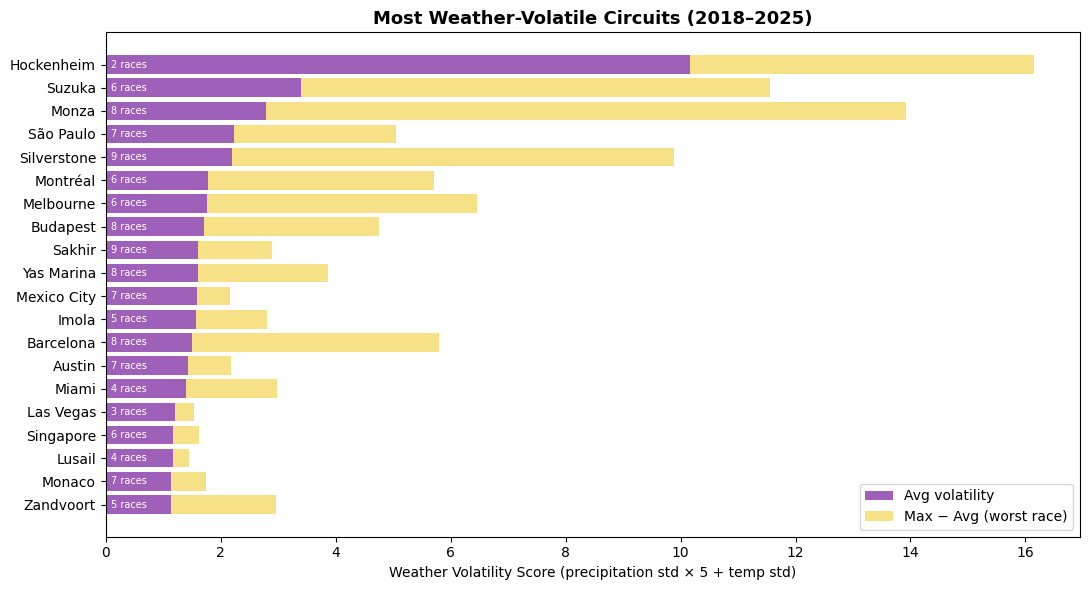

In [13]:
circuit_vol = (
    raw.groupby("Location")["volatility_score"]
    .agg(["mean", "max", "count"])
    .rename(columns={"mean": "avg_volatility", "max": "max_volatility", "count": "races"})
    .query("races >= 2")   # at least 2 data points per circuit
    .sort_values("avg_volatility", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(circuit_vol.index, circuit_vol["avg_volatility"], color=purple, alpha=0.85, label="Avg volatility")
ax.barh(circuit_vol.index, circuit_vol["max_volatility"] - circuit_vol["avg_volatility"],
        left=circuit_vol["avg_volatility"], color=yellow, alpha=0.5, label="Max − Avg (worst race)")

for i, (_, row) in enumerate(circuit_vol.iterrows()):
    ax.text(0.1, i, f"{row['races']:.0f} races", va="center", fontsize=7, color="white")

ax.set_xlabel("Weather Volatility Score (precipitation std × 5 + temp std)")
ax.set_title("Most Weather-Volatile Circuits (2018–2025)", fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
# plt.savefig("circuit_volatility.png", dpi=150)
plt.show()

### Wind gust spikes — sudden handling disruptions

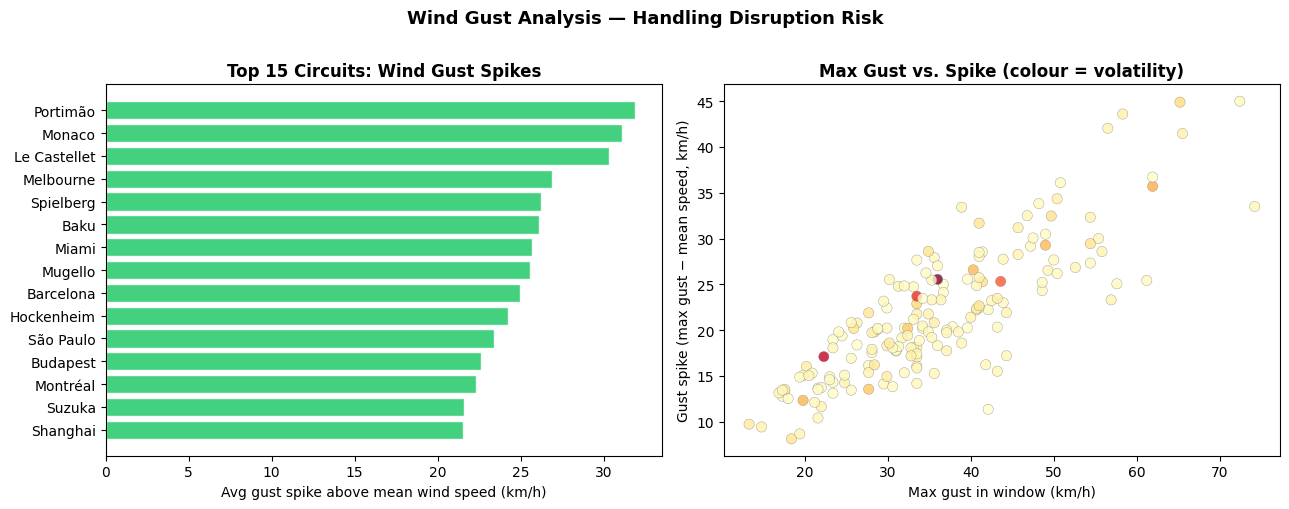

In [14]:
if raw["wind_gust_spike"].notna().any():
    spike_circuit = (
        raw.groupby("Location")["wind_gust_spike"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    ax.barh(spike_circuit.index, spike_circuit, color=green, edgecolor="white", alpha=0.9)
    ax.set_xlabel("Avg gust spike above mean wind speed (km/h)")
    ax.set_title("Top 15 Circuits: Wind Gust Spikes", fontsize=12, fontweight="bold")
    ax.invert_yaxis()

    ax = axes[1]
    ax.scatter(raw["wind_gust_max"], raw["wind_gust_spike"],
               c=raw["volatility_score"], cmap="YlOrRd",
               s=55, alpha=0.8, edgecolors="grey", linewidths=0.3)
    ax.set_xlabel("Max gust in window (km/h)")
    ax.set_ylabel("Gust spike (max gust − mean speed, km/h)")
    ax.set_title("Max Gust vs. Spike (colour = volatility)", fontsize=12, fontweight="bold")

    plt.suptitle("Wind Gust Analysis — Handling Disruption Risk",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    # plt.savefig("wind_gust_spikes.png", dpi=150)
    plt.show()
else:
    print("Wind gust data unavailable.")

### Season calendar heatmap — precipitation across rounds × years

/var/folders/pz/kh3w1p1d5sgg5tn3qkxmpccc0000gp/T/ipykernel_31873/3988357228.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot=pivot_precip.applymap(lambda v: f"{v:.1f}" if pd.notna(v) else ""),
/var/folders/pz/kh3w1p1d5sgg5tn3qkxmpccc0000gp/T/ipykernel_31873/3988357228.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot=pivot_temp.applymap(lambda v: f"{v:.0f}" if pd.notna(v) else ""),


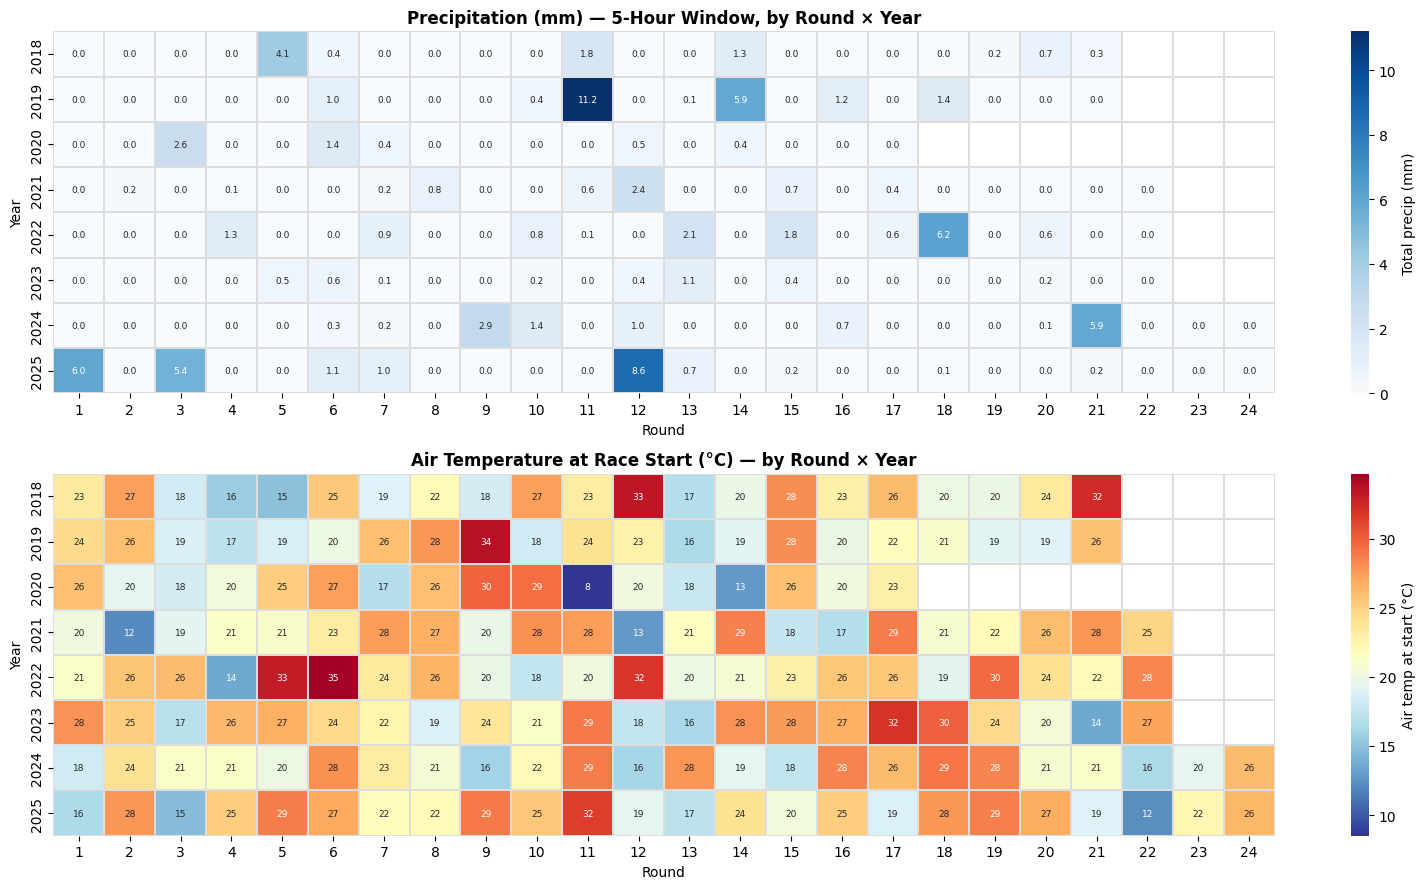

In [15]:
raw["Round"] = raw.groupby("Year")["StartTime"].rank(method="first").astype(int)

pivot_precip = raw.pivot_table(index="Year", columns="Round", values="precip_total", aggfunc="first")
pivot_temp   = raw.pivot_table(index="Year", columns="Round", values="temp_at_start",  aggfunc="first")

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

sns.heatmap(pivot_precip, ax=axes[0], cmap="Blues", linewidths=0.3, linecolor="#ddd",
            cbar_kws={"label": "Total precip (mm)"},
            annot=pivot_precip.applymap(lambda v: f"{v:.1f}" if pd.notna(v) else ""),
            fmt="", annot_kws={"size": 6.5})
axes[0].set_title("Precipitation (mm) — 5-Hour Window, by Round × Year",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Year")

sns.heatmap(pivot_temp, ax=axes[1], cmap="RdYlBu_r", linewidths=0.3, linecolor="#ddd",
            cbar_kws={"label": "Air temp at start (°C)"},
            annot=pivot_temp.applymap(lambda v: f"{v:.0f}" if pd.notna(v) else ""),
            fmt="", annot_kws={"size": 6.5})
axes[1].set_title("Air Temperature at Race Start (°C) — by Round × Year",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Year")

plt.tight_layout()
# plt.savefig("calendar_heatmap.png", dpi=150)
plt.show()

### Races misclassified by single-timestamp method

In [16]:
# Cases where the single-hour stamp said "dry" but extended window reveals rain
missed_wet = raw[~raw["is_wet_start"] & raw["is_wet_broad"]].copy()
false_wet  = raw[raw["is_wet_start"] & ~raw["is_wet_broad"]].copy()  # edge case: start wet but nothing else

print(f"Races missed as wet by single-timestamp: {len(missed_wet)}")
print(f"Races flagged wet at start but no other window rain: {len(false_wet)}")

if not missed_wet.empty:
    print("\n--- Races where track was wet (pre or post) but start hour read dry ---")
    show = ["Year", "EventName", "Location",
            "precip_pre2h", "precip_at_start", "precip_post2h",
            "track_wet_pre", "rain_during", "race_condition_profile"]
    show = [c for c in show if c in missed_wet.columns]
    print(missed_wet[show].sort_values("precip_pre2h", ascending=False).to_string(index=False))

Races missed as wet by single-timestamp: 21
Races flagged wet at start but no other window rain: 0

--- Races where track was wet (pre or post) but start hour read dry ---
 Year                 EventName          Location  precip_pre2h  precip_at_start  precip_post2h  track_wet_pre  rain_during race_condition_profile
 2019         German Grand Prix        Hockenheim          6.80             0.10           4.30           True         True          Sustained Wet
 2019        Italian Grand Prix             Monza          5.80             0.10           0.00           True        False                Wet→Dry
 2018        Italian Grand Prix             Monza          1.20             0.10           0.00           True        False                Wet→Dry
 2025 Emilia Romagna Grand Prix             Imola          1.00             0.00           0.00           True        False                Wet→Dry
 2025          Miami Grand Prix             Miami          0.90             0.00           0.

## 9 · Extreme conditions table (extended)

In [17]:
def safe_extreme(col: str, largest: bool = True) -> pd.Series | None:
    s = raw[col].dropna() if col in raw.columns else pd.Series(dtype=float)
    if s.empty:
        return None
    return raw.loc[s.idxmax() if largest else s.idxmin()]

extreme_specs = [
    ("Most rain (5-hr total)",        safe_extreme("precip_total")),
    ("Most pre-race rain",            safe_extreme("precip_pre2h")),
    ("Highest single-hour rain",      safe_extreme("precip_max_hr")),
    ("Hottest race start",            safe_extreme("temp_at_start")),
    ("Coldest race start",            safe_extreme("temp_at_start", False)),
    ("Largest thermal swing",         safe_extreme("temp_swing")),
    ("Highest wind gust",             safe_extreme("wind_gust_max")),
    ("Biggest gust spike",            safe_extreme("wind_gust_spike")),
    ("Most volatile weather",         safe_extreme("volatility_score")),
    ("Closest to condensation",       safe_extreme("dewpoint_margin_min", False)),
    ("Most wet hours in window",      safe_extreme("wet_hours_count")),
]

extreme_rows = []
for label, row in extreme_specs:
    if row is None:
        continue
    extreme_rows.append({
        "Condition":        label,
        "Year":             row.get("Year"),
        "Event":            row.get("EventName"),
        "Air °C":           row.get("temp_at_start"),
        "Precip total mm":  row.get("precip_total"),
        "Precip pre mm":    row.get("precip_pre2h"),
        "Wind gust km/h":   row.get("wind_gust_max"),
        "Volatility":       row.get("volatility_score"),
        "Profile":          row.get("race_condition_profile"),
    })

pd.DataFrame(extreme_rows).set_index("Condition").style.format(na_rep="–", precision=2)

,Year,Event,Air °C,Precip total mm,Precip pre mm,Wind gust km/h,Volatility,Profile
Condition,,,,,,,,
Most rain (5-hr total),2019,German Grand Prix,24.00,11.20,6.80,36.00,16.14,Sustained Wet
Most pre-race rain,2019,German Grand Prix,24.00,11.20,6.80,36.00,16.14,Sustained Wet
Highest single-hour rain,2019,German Grand Prix,24.00,11.20,6.80,36.00,16.14,Sustained Wet
Hottest race start,2022,Spanish Grand Prix,34.70,0.00,0.00,47.20,0.82,Dry
Coldest race start,2020,Eifel Grand Prix,8.50,0.00,0.00,31.00,0.33,Dry
Largest thermal swing,2018,Abu Dhabi Grand Prix,32.40,0.30,0.00,65.20,3.87,Dry→Wet
Highest wind gust,2018,Azerbaijan Grand Prix,15.60,0.00,0.00,74.20,1.16,Dry
Biggest gust spike,2019,Japanese Grand Prix,21.70,0.00,0.00,72.40,0.85,Dry
Most volatile weather,2019,German Grand Prix,24.00,11.20,6.80,36.00,16.14,Sustained Wet
